In [1]:
import pandas as pd

df = pd.read_csv("hour.csv")

# Drop unnecessary columns
drop_cols = ['instant', 'dteday', 'casual', 'registered']
df.drop(columns=drop_cols, inplace=True)

df.head()


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [2]:
df.isnull().sum()


season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

In [3]:
df.describe()


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,189.463088
std,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,181.387599
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,40.000000
50%,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,142.000000
75%,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,281.000000
max,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,977.000000


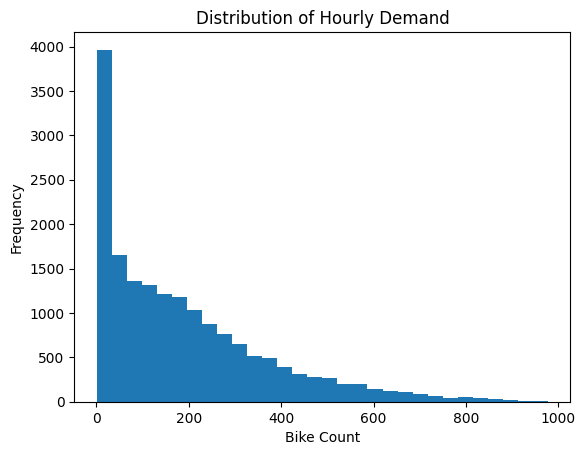

In [4]:
import matplotlib.pyplot as plt

plt.hist(df['cnt'], bins=30)
plt.xlabel("Bike Count")
plt.ylabel("Frequency")
plt.title("Distribution of Hourly Demand")
plt.show()


In [5]:
Q1 = df['cnt'].quantile(0.25)
Q3 = df['cnt'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['cnt'] >= lower) & (df['cnt'] <= upper)]


In [6]:
df.isnull().sum()


season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

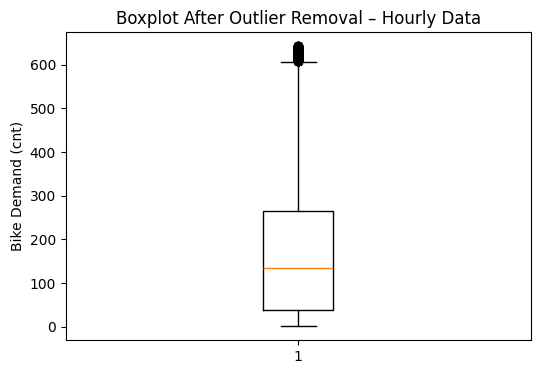

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.boxplot(df['cnt'], vert=True)
plt.ylabel("Bike Demand (cnt)")
plt.title("Boxplot After Outlier Removal – Hourly Data")
plt.show()


In [8]:
X = df.drop('cnt', axis=1)
y = df['cnt']


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}


In [12]:
gbr = GradientBoostingRegressor(random_state=42)

grid = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)


Fitting 3 folds for each of 36 candidates, totalling 108 fits


,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.8, 1.0]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [13]:
grid.best_params_


{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}

In [14]:
best_gbr = grid.best_estimator_


In [15]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_train_pred = best_gbr.predict(X_train)
y_test_pred = best_gbr.predict(X_test)

print("TRAIN RESULTS")
print("R2:", r2_score(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))

print("\nTEST RESULTS")
print("R2:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))


TRAIN RESULTS
R2: 0.9598667015446543
MAE: 20.510186566955202

TEST RESULTS
R2: 0.9410526186290484
MAE: 24.248716402088288
RMSE: 37.05836786951488


In [ ]:
results = pd.DataFrame(grid.cv_results_)

results[['params', 'mean_test_score', 'rank_test_score']].sort_values(
    by='rank_test_score'
).head()


,params,mean_test_score,rank_test_score
34,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.932982,1
32,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.928871,2
35,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.928657,3
16,"{'learning_rate': 0.05, 'max_depth': 5, 'n_est...",0.926394,4
33,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.925321,5


: 